<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/gn_hcf_two_paper_validation_colab_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GN model + DNANF geometry model: two-paper validation

This Colab validates the current analytical code without using digitized curves as model inputs.

**References**

1. P. Poggiolini, “The GN Model of Non-Linear Propagation in Uncompensated Coherent Optical Systems,” *JLT* 30(24), 3857–3879 (2012), DOI 10.1109/JLT.2012.2217729. [Publisher](https://opg.optica.org/jlt/abstract.cfm?uri=jlt-30-24-3857) · [author post-print record](https://iris.polito.it/handle/11583/2506445)
2. M. Petrovich *et al.*, “Broadband optical fibre with an attenuation lower than 0.1 decibel per kilometre,” *Nature Photonics* 19, 1203–1208 (2025), DOI 10.1038/s41566-025-01747-5. [Article](https://www.nature.com/articles/s41566-025-01747-5) · [arXiv preprint](https://arxiv.org/abs/2503.21467)
3. [Current GitHub code](https://github.com/kimheeseo/LSCNS/tree/main/paper/hcf-optimum-launch-power-reproduction)

## Interpretation rules

- **Raw** = geometry-only Hasan coefficients; no paper-value fitting.
- **Current calibrated** = the repository's existing `f1/f2` least-squares calibration to 2.17 and 3.20 ps/(nm·km) at 1,310 and 1,550 nm.
- The repository's present non-Nyquist `closed_form_gn_eta()` is retained as the GN function under test. Poggiolini Eq. (13) is calculated only as a reference; it does not replace the current function.
- The Petrovich values 2.1, 3.2 and 3.7 ps/(nm·km) are used only for comparison. The 1,700-nm point is a hold-out point.
- The loss fit is separate from `f1/f2`; changing `f1/f2` does not change the current loss function.
- Percentage error is `(simulation-reference)/reference × 100`; MAPE uses absolute values.
- A result is flagged when absolute error is at least 10%.


In [1]:
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

C0 = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
U01 = 2.4048255577
DB_PER_NEPER = 10.0 / np.log(10.0)
ERROR_THRESHOLD_PERCENT = 10.0

print("Validation notebook ready.")


Validation notebook ready.


## 1. GN-model verification against Poggiolini (2012)

The paper is primarily a theory/model paper, not a transmission experiment. Therefore two checks are used:

1. **Equation implementation check:** current `closed_form_gn_eta()` versus paper Eq. (13) for the three single-span Nyquist-WDM reference fibres in Table I.
2. **Direct numerical-example check:** optimum launch powers explicitly stated in Section XII of the paper.

This verifies consistency with the reference paper. It is not independent experimental validation of the GN assumptions.

**Important:** the current 140-GBd/150-GHz non-Nyquist GN formula is not replaced by Eq. (13). The Eq. (13) implementation below is a benchmark function used only under the paper's single-span Nyquist reference conditions.


In [2]:
@dataclass(frozen=True)
class GNFiber:
    name: str
    attenuation_db_km: float
    dispersion_ps_nm_km: float
    gamma_per_w_km: float


GN_FIBERS = [
    GNFiber("LPSCF", 0.165, 20.4, 0.8),
    GNFiber("SMF",   0.200, 16.5, 1.3),
    GNFiber("NZDSF", 0.200,  3.9, 1.6),
]

GN_FIXED = {
    "wavelength_nm": 1550.0,
    "span_length_km": 100.0,
    "symbol_rate_GBd": 32.0,
    "spacing_GHz": 32.0,
    "n_channels": 157,
    "WDM": "ideal rectangular Nyquist-WDM",
    "n_spans": 1,
    "polarization_factor": "16/27 Manakov/GN reference factor",
}

gn_input_table = pd.DataFrame([vars(f) for f in GN_FIBERS])
gn_fixed_table = pd.DataFrame(
    [(k, v) for k, v in GN_FIXED.items()], columns=["Fixed item", "Value"]
)

print("[GN variable inputs — Poggiolini Table I]")
display(gn_input_table)
print("[GN fixed values / assumptions]")
display(gn_fixed_table)


[GN variable inputs — Poggiolini Table I]


,name,attenuation_db_km,dispersion_ps_nm_km,gamma_per_w_km
0,LPSCF,0.165,20.4,0.8
1,SMF,0.200,16.5,1.3
2,NZDSF,0.200,3.9,1.6


[GN fixed values / assumptions]


,Fixed item,Value
0,wavelength_nm,1550.0
1,span_length_km,100.0
2,symbol_rate_GBd,32.0
3,spacing_GHz,32.0
4,n_channels,157
5,WDM,ideal rectangular Nyquist-WDM
6,n_spans,1
7,polarization_factor,16/27 Manakov/GN reference factor


In [3]:
def beta2_s2_per_km(dispersion_ps_nm_km, wavelength_nm=1550.0):
    wavelength_m = wavelength_nm * 1e-9
    dispersion_si = dispersion_ps_nm_km * 1e-6
    return abs(-(wavelength_m**2 / (2.0 * np.pi * C0)) * dispersion_si * 1000.0)


def current_code_eta(fiber, span_length_km, symbol_rate_hz, spacing_hz, n_channels):
    # Repository closed-form structure, unchanged.
    beta2 = beta2_s2_per_km(fiber.dispersion_ps_nm_km)
    alpha_field = fiber.attenuation_db_km / 8.685889638
    argument = (
        np.pi**2 * beta2 * symbol_rate_hz**2 / (4.0 * alpha_field)
        * n_channels ** (2.0 * symbol_rate_hz / spacing_hz)
    )
    return (
        4.0 * fiber.gamma_per_w_km**2
        / (27.0 * np.pi * beta2 * alpha_field * symbol_rate_hz**2)
        * np.arcsinh(argument)
    )


def paper_eq13_eta(fiber, span_length_km, symbol_rate_hz, n_channels):
    # Poggiolini (2012) Eq. (13), converted from PSD to P_NLI/P_ch^3.
    beta2 = beta2_s2_per_km(fiber.dispersion_ps_nm_km)
    alpha_field = fiber.attenuation_db_km / 8.685889638
    leff = (1.0 - np.exp(-2.0 * alpha_field * span_length_km)) / (2.0 * alpha_field)
    leff_a = 1.0 / (2.0 * alpha_field)
    bandwidth_hz = n_channels * symbol_rate_hz
    gnli_over_gwdm_cubed = (
        8.0 / 27.0
        * fiber.gamma_per_w_km**2
        * leff**2
        * np.arcsinh(0.5 * np.pi**2 * beta2 * leff_a * bandwidth_hz**2)
        / (np.pi * beta2 * leff_a)
    )
    return gnli_over_gwdm_cubed / symbol_rate_hz**2


gn_rows = []
for fiber in GN_FIBERS:
    rs = GN_FIXED["symbol_rate_GBd"] * 1e9
    spacing = GN_FIXED["spacing_GHz"] * 1e9
    paper_eta = paper_eq13_eta(fiber, GN_FIXED["span_length_km"], rs, GN_FIXED["n_channels"])
    code_eta = current_code_eta(
        fiber, GN_FIXED["span_length_km"], rs, spacing, GN_FIXED["n_channels"]
    )
    signed_error = 100.0 * (code_eta - paper_eta) / paper_eta
    gn_rows.append({
        "Fiber": fiber.name,
        "beta2 (s^2/km)": beta2_s2_per_km(fiber.dispersion_ps_nm_km),
        "Paper Eq.13 eta (1/W^2)": paper_eta,
        "Current-code eta (1/W^2)": code_eta,
        "Signed error (%)": signed_error,
        "Absolute error (%)": abs(signed_error),
        "10% flag": abs(signed_error) >= ERROR_THRESHOLD_PERCENT,
    })

gn_eta_comparison = pd.DataFrame(gn_rows)
print("[GN outputs — Eq. (13) consistency]")
display(gn_eta_comparison)
print(f"GN eta MAPE = {gn_eta_comparison['Absolute error (%)'].mean():.3f}%")


[GN outputs — Eq. (13) consistency]


,Fiber,beta2 (s^2/km),Paper Eq.13 eta (1/W^2),Current-code eta (1/W^2),Signed error (%),Absolute error (%),10% flag
0,LPSCF,2.601914e-23,686.562820,718.367263,4.632416,4.632416,False
1,SMF,2.104490e-23,1832.692336,1869.903414,2.030405,2.030405,False
2,NZDSF,4.974248e-24,10290.141722,10499.073280,2.030405,2.030405,False


GN eta MAPE = 2.898%


In [4]:
@dataclass(frozen=True)
class GNLaunchCase:
    name: str
    n_channels: int
    spacing_ghz: float
    span_km: float
    paper_popt_dbm: float


PAPER_LAUNCH_CASES = [
    GNLaunchCase("RS-SMF, 100 km", 101, 50.0, 100.0, -0.4),
    GNLaunchCase("NY-SMF, 100 km", 157, 32.0, 100.0, -1.0),
    GNLaunchCase("NY-SMF, 75 km",  157, 32.0,  75.0, -2.6),
]


def current_code_optimum_launch_dbm(case, noise_figure_db=6.0):
    fiber = next(f for f in GN_FIBERS if f.name == "SMF")
    rs = 32e9
    eta = current_code_eta(fiber, case.span_km, rs, case.spacing_ghz * 1e9, case.n_channels)
    frequency_hz = C0 / 1550e-9
    noise_factor = 10.0 ** (noise_figure_db / 10.0)
    gain = 10.0 ** (fiber.attenuation_db_km * case.span_km / 10.0)
    ase_w = H_PLANCK * frequency_hz * noise_factor * rs * (gain - 1.0)
    # Maximize P/(ASE + eta*P^3): Popt^3 = ASE/(2*eta)
    popt_w = (ase_w / (2.0 * eta)) ** (1.0 / 3.0)
    return 10.0 * np.log10(popt_w) + 30.0, popt_w, eta, ase_w


popt_rows = []
for case in PAPER_LAUNCH_CASES:
    model_dbm, model_w, eta, ase_w = current_code_optimum_launch_dbm(case)
    paper_w = 10.0 ** ((case.paper_popt_dbm - 30.0) / 10.0)
    power_error = 100.0 * (model_w - paper_w) / paper_w
    popt_rows.append({
        "Case": case.name,
        "Nch": case.n_channels,
        "Spacing (GHz)": case.spacing_ghz,
        "Span (km)": case.span_km,
        "Paper Popt (dBm/ch)": case.paper_popt_dbm,
        "Current code (dBm/ch)": model_dbm,
        "Difference (dB)": model_dbm - case.paper_popt_dbm,
        "Linear-power error (%)": power_error,
        "Absolute power error (%)": abs(power_error),
        "10% flag": abs(power_error) >= ERROR_THRESHOLD_PERCENT,
    })

gn_popt_comparison = pd.DataFrame(popt_rows)
print("[GN outputs — paper's explicit optimum-launch examples]")
display(gn_popt_comparison)


[GN outputs — paper's explicit optimum-launch examples]


,Case,Nch,Spacing (GHz),Span (km),Paper Popt (dBm/ch),Current code (dBm/ch),Difference (dB),Linear-power error (%),Absolute power error (%),10% flag
0,"RS-SMF, 100 km",101,50.0,100.0,-0.4,-0.565643,-0.165643,-3.742258,3.742258,False
1,"NY-SMF, 100 km",157,32.0,100.0,-1.0,-1.214397,-0.214397,-4.816790,4.816790,False
2,"NY-SMF, 75 km",157,32.0,75.0,-2.6,-2.913032,-0.313032,-6.954194,6.954194,False


In [5]:
def print_threshold_comments(df, label, error_col, reasons):
    flagged = df[df[error_col] >= ERROR_THRESHOLD_PERCENT]
    print(f"[{label}: >= {ERROR_THRESHOLD_PERCENT:.0f}% comments]")
    if flagged.empty:
        print("No >=10% item. The tested implementation is consistent within the selected benchmark conditions.")
    else:
        for _, row in flagged.iterrows():
            print("-", reasons(row))


print_threshold_comments(
    gn_eta_comparison,
    "GN eta",
    "Absolute error (%)",
    lambda r: f"{r['Fiber']}: {r['Absolute error (%)']:.2f}% — check the finite-span effective-length approximation and the Eq. (13) validity assumptions.",
)
print_threshold_comments(
    gn_popt_comparison,
    "GN optimum launch",
    "Absolute power error (%)",
    lambda r: f"{r['Case']}: {r['Absolute power error (%)']:.2f}% — the RS raised-cosine spectrum is approximated by the repository's compact closed form.",
)


[GN eta: >= 10% comments]
No >=10% item. The tested implementation is consistent within the selected benchmark conditions.
[GN optimum launch: >= 10% comments]
No >=10% item. The tested implementation is consistent within the selected benchmark conditions.


## 2. HCF2 geometry and dispersion verification against Petrovich et al. (2025)

### Variable inputs

The code uses the reported nominal HCF2 geometry. The paper reports longitudinal/azimuthal ranges, whereas the analytical code uses one representative scalar per dimension.

### Fixed values

- Air-core index is approximated as 1.
- Fundamental capillary root: `u01 = 2.4048255577`.
- Modified Marcatili–Schmeltzer effective-index approximation.
- Dispersion from a five-point second derivative with 0.20-nm step.
- The current analytical model uses the outer large-tube diameter but **does not directly use the reported middle- and small-tube diameters**.


In [6]:
@dataclass(frozen=True)
class DNANFGeometry:
    core_radius_um: float = 14.75
    membrane_thickness_um: float = 0.50
    outer_tube_diameter_um: float = 31.05
    tube_count: int = 5
    nesting_order: int = 2

    @property
    def core_radius_m(self):
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self):
        return self.membrane_thickness_um * 1e-6

    @property
    def perimeter_gap_m(self):
        theta = np.pi / self.tube_count
        return (
            2.0 * self.core_radius_m * np.sin(theta)
            - self.outer_tube_diameter_um * 1e-6 * (1.0 - np.sin(theta))
        )


geometry = DNANFGeometry()

hcf_geometry_inputs = pd.DataFrame([
    ["Core diameter", "29.1–29.6 µm; nominal 29.5 µm", 2*geometry.core_radius_um, "Used"],
    ["Large tube diameter", "30.4–31.7 µm", geometry.outer_tube_diameter_um, "Used"],
    ["Middle tube diameter", "22.7–24.8 µm", "not represented", "Not used by current equations"],
    ["Small tube diameter", "7.0–8.4 µm", "not represented", "Not used by current equations"],
    ["Membrane thickness", "around 0.50 µm", geometry.membrane_thickness_um, "Used"],
    ["Outer tube count", "5", geometry.tube_count, "Used"],
    ["Nested sets/order", "two nested sets", geometry.nesting_order, "Used only in Hasan correction"],
], columns=["Input", "Paper HCF2", "Code value", "Use in current model"])

hcf_fixed_values = pd.DataFrame([
    ["u01", U01, "fundamental capillary mode"],
    ["c", C0, "m/s"],
    ["air-core refractive index", 1.0, "fixed approximation"],
    ["finite-difference step", 0.20, "nm"],
], columns=["Fixed item", "Value", "Meaning/unit"])

print("[HCF variable inputs]")
display(hcf_geometry_inputs)
print("[HCF fixed values]")
display(hcf_fixed_values)


[HCF variable inputs]


,Input,Paper HCF2,Code value,Use in current model
0,Core diameter,29.1–29.6 µm; nominal 29.5 µm,29.5,Used
1,Large tube diameter,30.4–31.7 µm,31.05,Used
2,Middle tube diameter,22.7–24.8 µm,not represented,Not used by current equations
3,Small tube diameter,7.0–8.4 µm,not represented,Not used by current equations
4,Membrane thickness,around 0.50 µm,0.5,Used
5,Outer tube count,5,5,Used
6,Nested sets/order,two nested sets,2,Used only in Hasan correction


[HCF fixed values]


,Fixed item,Value,Meaning/unit
0,u01,2.404826e+00,fundamental capillary mode
1,c,2.997925e+08,m/s
2,air-core refractive index,1.000000e+00,fixed approximation
3,finite-difference step,2.000000e-01,nm


In [7]:
def hasan_radius_coefficients(geometry):
    radius_to_gap = geometry.core_radius_m / geometry.perimeter_gap_m
    n = geometry.tube_count
    nesting = geometry.nesting_order
    a0, a1 = 0.097041, 1.095
    b0, b1, b2, b3 = 0.76246, 0.007584, 0.002, 0.012
    f1 = a1 * np.exp(a0 / radius_to_gap)
    f2 = (
        b1 * n * np.exp(b0 / radius_to_gap)
        - b2 * n + b3
        + 0.0045 * np.exp(-4.1589 / (nesting * radius_to_gap))
    )
    return float(f1), float(f2)


def effective_radius_m(wavelength_m, geometry, f1, f2):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    return f1 * geometry.core_radius_m * (
        1.0 - f2 * wavelength_m**2
        / (geometry.core_radius_m * geometry.membrane_thickness_m)
    )


def effective_index(wavelength_m, geometry, f1, f2):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    reff = effective_radius_m(wavelength_m, geometry, f1, f2)
    return 1.0 - 0.125 * (U01 * wavelength_m / (np.pi * reff)) ** 2


def chromatic_dispersion_ps_nm_km(wavelength_m, geometry, f1, f2, derivative_step_nm=0.20):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    h = derivative_step_nm * 1e-9
    def n_eff(offset):
        return effective_index(wavelength_m + offset, geometry, f1, f2)
    d2n = (
        -n_eff(2*h) + 16*n_eff(h) - 30*n_eff(0.0)
        + 16*n_eff(-h) - n_eff(-2*h)
    ) / (12*h**2)
    return -(wavelength_m / C0) * d2n / 1e-6


def current_repository_calibration(geometry):
    # Exactly the repository branch: target 2.17 and 3.20 at 1310/1550 nm.
    calibration_nm = np.array([1310.0, 1550.0])
    calibration_d = np.array([2.17, 3.20])
    initial = np.array(hasan_radius_coefficients(geometry))
    def residual(p):
        return chromatic_dispersion_ps_nm_km(
            calibration_nm*1e-9, geometry, p[0], p[1]
        ) - calibration_d
    result = least_squares(
        residual, initial,
        bounds=(np.array([0.5, -0.5]), np.array([2.5, 1.0])),
        x_scale="jac", diff_step=1e-3,
        xtol=1e-13, ftol=1e-13, gtol=1e-13,
    )
    if not result.success:
        raise RuntimeError(result.message)
    return float(result.x[0]), float(result.x[1])


raw_f1, raw_f2 = hasan_radius_coefficients(geometry)
cal_f1, cal_f2 = current_repository_calibration(geometry)

coefficient_table = pd.DataFrame([
    ["Raw Hasan (no fitting)", raw_f1, raw_f2, "Independent geometry-only branch"],
    ["Current repository calibrated", cal_f1, cal_f2, "Fit to 2.17/3.20 at 1310/1550 nm"],
], columns=["Mode", "f1", "f2", "Meaning"])

geometry_derived = pd.DataFrame([
    ["Inferred perimeter gap", geometry.perimeter_gap_m*1e6, "µm"],
    ["Core radius / gap", geometry.core_radius_m/geometry.perimeter_gap_m, "dimensionless"],
], columns=["Derived geometry output", "Value", "Unit"])

print("[Derived geometry outputs]")
display(geometry_derived)
print("[f1/f2 outputs]")
display(coefficient_table)


[Derived geometry outputs]


,Derived geometry output,Value,Unit
0,Inferred perimeter gap,4.540397,µm
1,Core radius / gap,3.248615,dimensionless


[f1/f2 outputs]


,Mode,f1,f2,Meaning
0,Raw Hasan (no fitting),1.128203,0.052324,Independent geometry-only branch
1,Current repository calibrated,1.583810,0.244140,Fit to 2.17/3.20 at 1310/1550 nm


In [8]:
PAPER_WAVELENGTH_NM = np.array([1310.0, 1550.0, 1700.0])
PAPER_DISPERSION = np.array([2.1, 3.2, 3.7])

dispersion_rows = []
mode_parameters = [
    ("Raw Hasan — no fitting", raw_f1, raw_f2),
    ("Current f1/f2 calibrated", cal_f1, cal_f2),
]

for mode, f1, f2 in mode_parameters:
    model_d = chromatic_dispersion_ps_nm_km(
        PAPER_WAVELENGTH_NM*1e-9, geometry, f1, f2
    )
    reff_um = effective_radius_m(PAPER_WAVELENGTH_NM*1e-9, geometry, f1, f2)*1e6
    neff = effective_index(PAPER_WAVELENGTH_NM*1e-9, geometry, f1, f2)
    for wavelength, paper_d, calc_d, radius, index in zip(
        PAPER_WAVELENGTH_NM, PAPER_DISPERSION, model_d, reff_um, neff
    ):
        signed_error = 100.0 * (calc_d-paper_d)/paper_d
        if mode.startswith("Current") and wavelength in (1310.0, 1550.0):
            status = "Calibration-near point; not independent validation"
        elif wavelength == 1700.0:
            status = "Hold-out point"
        else:
            status = "Independent raw prediction"
        dispersion_rows.append({
            "Mode": mode,
            "Wavelength (nm)": wavelength,
            "Paper D (ps/nm/km)": paper_d,
            "Model D (ps/nm/km)": calc_d,
            "Signed error (%)": signed_error,
            "Absolute error (%)": abs(signed_error),
            "Reff (um)": radius,
            "neff": index,
            "Evaluation status": status,
            "10% flag": abs(signed_error) >= ERROR_THRESHOLD_PERCENT,
        })

dispersion_comparison = pd.DataFrame(dispersion_rows)
print("[HCF outputs — dispersion, Reff and neff]")
display(dispersion_comparison)

dispersion_summary = (
    dispersion_comparison.groupby("Mode", as_index=False)
    .agg(MAPE_percent=("Absolute error (%)", "mean"), Max_error_percent=("Absolute error (%)", "max"))
)
display(dispersion_summary)


[HCF outputs — dispersion, Reff and neff]


,Mode,Wavelength (nm),Paper D (ps/nm/km),Model D (ps/nm/km),Signed error (%),Absolute error (%),Reff (um),neff,Evaluation status,10% flag
0,Raw Hasan — no fitting,1310.0,2.1,2.665145,26.911661,26.911661,16.438382,0.999535,Independent raw prediction,True
1,Raw Hasan — no fitting,1550.0,3.2,3.331737,4.116794,4.116794,16.357343,0.999342,Independent raw prediction,False
2,Raw Hasan — no fitting,1700.0,3.7,3.797515,2.635537,2.635537,16.299787,0.999203,Hold-out point,False
3,Current f1/f2 calibrated,1310.0,2.1,2.169998,3.333234,3.333234,22.034071,0.999741,Calibration-near point; not independent valida...,False
4,Current f1/f2 calibrated,1550.0,3.2,3.200004,0.000124,0.000124,21.503248,0.999619,Calibration-near point; not independent valida...,False
5,Current f1/f2 calibrated,1700.0,3.7,4.080066,10.272059,10.272059,21.126244,0.999526,Hold-out point,True


,Mode,MAPE_percent,Max_error_percent
0,Current f1/f2 calibrated,4.535139,10.272059
1,Raw Hasan — no fitting,11.221330,26.911661


In [9]:
print_threshold_comments(
    dispersion_comparison,
    "HCF dispersion",
    "Absolute error (%)",
    lambda r: (
        f"{r['Mode']}, {r['Wavelength (nm)']:.0f} nm: {r['Absolute error (%)']:.2f}% — "
        + ("the Hasan fit was developed for a restricted geometry family and n=5 is an extrapolation; the scalar capillary surrogate omits exact middle/small tubes and structural variation."
           if r['Mode'].startswith('Raw') else
           "two fitted coefficients force two spectral points but do not reproduce the full-vector dispersion curvature at the 1700-nm hold-out point.")
    ),
)


[HCF dispersion: >= 10% comments]
- Raw Hasan — no fitting, 1310 nm: 26.91% — the Hasan fit was developed for a restricted geometry family and n=5 is an extrapolation; the scalar capillary surrogate omits exact middle/small tubes and structural variation.
- Current f1/f2 calibrated, 1700 nm: 10.27% — two fitted coefficients force two spectral points but do not reproduce the full-vector dispersion curvature at the 1700-nm hold-out point.


## 3. HCF2 attenuation check

`f1/f2` are not inputs to the current loss function. The loss check therefore has separate modes:

- **Raw bouncing-ray:** absolute thin-wall capillary leakage. It is not a DNANF total-loss prediction.
- **Current hybrid:** surface-scattering proxy plus normalized squared bouncing-ray proxy, calibrated in the repository to 0.120 dB/km at 1,310 nm and 0.075 dB/km at 1,550 nm.
- **Petrovich measured HCF2:** 0.128 and 0.091 dB/km at 1,310 and 1,550 nm.

The Petrovich paper also gives 0.070 dB/km at 1,550 nm for an idealized, perfectly uniform nominal geometry. This is shown separately from measurement.


In [10]:
def silica_index_sellmeier(wavelength_m):
    wavelength_um = np.asarray(wavelength_m, dtype=float) * 1e6
    wavelength_um_sq = wavelength_um**2
    b = np.array([0.6961663, 0.4079426, 0.8974794])
    c_um = np.array([0.0684043, 0.1162414, 9.896161])
    n_sq = np.ones_like(wavelength_um_sq)
    for bi, ci in zip(b, c_um):
        n_sq += bi*wavelength_um_sq/(wavelength_um_sq-ci**2)
    return np.sqrt(n_sq)


def capillary_bouncing_ray_loss_db_km(wavelength_m, geometry):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    k0 = 2*np.pi/wavelength_m
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    kappa = U01/radius
    silica_n = silica_index_sellmeier(wavelength_m)
    sigma = k0*np.sqrt(silica_n**2-1.0)
    phase = sigma*wall
    te_den = 4*np.cos(phase)**2 + (kappa/sigma+sigma/kappa)**2*np.sin(phase)**2
    tm_den = 4*np.cos(phase)**2 + (silica_n**2*kappa/sigma+sigma/(silica_n**2*kappa))**2*np.sin(phase)**2
    alpha_te = 2*U01/(radius**2*k0*te_den)
    alpha_tm = 2*U01/(radius**2*k0*tm_den)
    return 0.5*(alpha_te+alpha_tm)*DB_PER_NEPER*1000.0


def current_hybrid_attenuation_db_km(wavelength_m, geometry):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    reference_nm = np.array([1550.0, 1310.0])
    code_targets = np.array([0.075, 0.120])
    lambda_ref = 1550e-9
    br_ref = capillary_bouncing_ray_loss_db_km(reference_nm*1e-9, geometry)
    basis_ref = np.column_stack([
        (lambda_ref/(reference_nm*1e-9))**3,
        (br_ref/br_ref[0])**2,
    ])
    a_surface, a_nested = np.linalg.solve(basis_ref, code_targets)
    br = capillary_bouncing_ray_loss_db_km(wavelength_m, geometry)
    total = a_surface*(lambda_ref/wavelength_m)**3 + a_nested*(br/br_ref[0])**2
    return total, a_surface, a_nested


loss_nm = np.array([1310.0, 1550.0])
paper_measured_loss = np.array([0.128, 0.091])
raw_br_loss = capillary_bouncing_ray_loss_db_km(loss_nm*1e-9, geometry)
hybrid_loss, a_surface, a_nested = current_hybrid_attenuation_db_km(loss_nm*1e-9, geometry)

loss_rows = []
for mode, values in [
    ("Raw bouncing-ray (not DNANF total loss)", raw_br_loss),
    ("Current hybrid loss", hybrid_loss),
]:
    for wavelength, ref, value in zip(loss_nm, paper_measured_loss, values):
        signed_error = 100*(value-ref)/ref
        loss_rows.append({
            "Mode": mode,
            "Wavelength (nm)": wavelength,
            "Paper measured (dB/km)": ref,
            "Model (dB/km)": value,
            "Signed error (%)": signed_error,
            "Absolute error (%)": abs(signed_error),
            "10% flag": abs(signed_error) >= ERROR_THRESHOLD_PERCENT,
        })

loss_comparison = pd.DataFrame(loss_rows)
loss_weights = pd.DataFrame([
    ["A_surface", a_surface, "dB/km"],
    ["A_nested", a_nested, "dB/km"],
], columns=["Output coefficient", "Value", "Unit"])

ideal_1550 = 0.070
hybrid_1550 = hybrid_loss[1]
ideal_error = 100*(hybrid_1550-ideal_1550)/ideal_1550

print("[Loss fixed/model outputs]")
display(loss_weights)
print("[Loss outputs — measured HCF2 reference]")
display(loss_comparison)
print(f"Current hybrid vs paper ideal 1550-nm loss: {hybrid_1550:.3f} vs {ideal_1550:.3f} dB/km; error={ideal_error:+.3f}%")


[Loss fixed/model outputs]


,Output coefficient,Value,Unit
0,A_surface,0.038679,dB/km
1,A_nested,0.036321,dB/km


[Loss outputs — measured HCF2 reference]


,Mode,Wavelength (nm),Paper measured (dB/km),Model (dB/km),Signed error (%),Absolute error (%),10% flag
0,Raw bouncing-ray (not DNANF total loss),1310.0,0.128,156381.450860,1.221729e+08,1.221729e+08,True
1,Raw bouncing-ray (not DNANF total loss),1550.0,0.091,126020.874408,1.384844e+08,1.384844e+08,True
2,Current hybrid loss,1310.0,0.128,0.120000,-6.250000e+00,6.250000e+00,False
3,Current hybrid loss,1550.0,0.091,0.075000,-1.758242e+01,1.758242e+01,True


Current hybrid vs paper ideal 1550-nm loss: 0.075 vs 0.070 dB/km; error=+7.143%


In [11]:
print_threshold_comments(
    loss_comparison,
    "HCF loss",
    "Absolute error (%)",
    lambda r: (
        f"{r['Mode']}, {r['Wavelength (nm)']:.0f} nm: {r['Absolute error (%)']:.2f}% — "
        + ("the thin-wall capillary bouncing-ray value is only a leakage proxy; it lacks the double-nested suppression and is not meant to equal measured total DNANF loss."
           if r['Mode'].startswith('Raw') else
           "the hybrid weights were calibrated to a different target dataset (0.120/0.075), while HCF2 measurement is 0.128/0.091; microbend, gas absorption, exact full-vector leakage and structural non-uniformity are omitted.")
    ),
)


[HCF loss: >= 10% comments]
- Raw bouncing-ray (not DNANF total loss), 1310 nm: 122172908.48% — the thin-wall capillary bouncing-ray value is only a leakage proxy; it lacks the double-nested suppression and is not meant to equal measured total DNANF loss.
- Raw bouncing-ray (not DNANF total loss), 1550 nm: 138484377.37% — the thin-wall capillary bouncing-ray value is only a leakage proxy; it lacks the double-nested suppression and is not meant to equal measured total DNANF loss.
- Current hybrid loss, 1550 nm: 17.58% — the hybrid weights were calibrated to a different target dataset (0.120/0.075), while HCF2 measurement is 0.128/0.091; microbend, gas absorption, exact full-vector leakage and structural non-uniformity are omitted.


## 4. Plots and saved tables

The figures and CSV tables below are generated entirely from the equations and scalar reference values above. No paper curve is used as a fitting array.


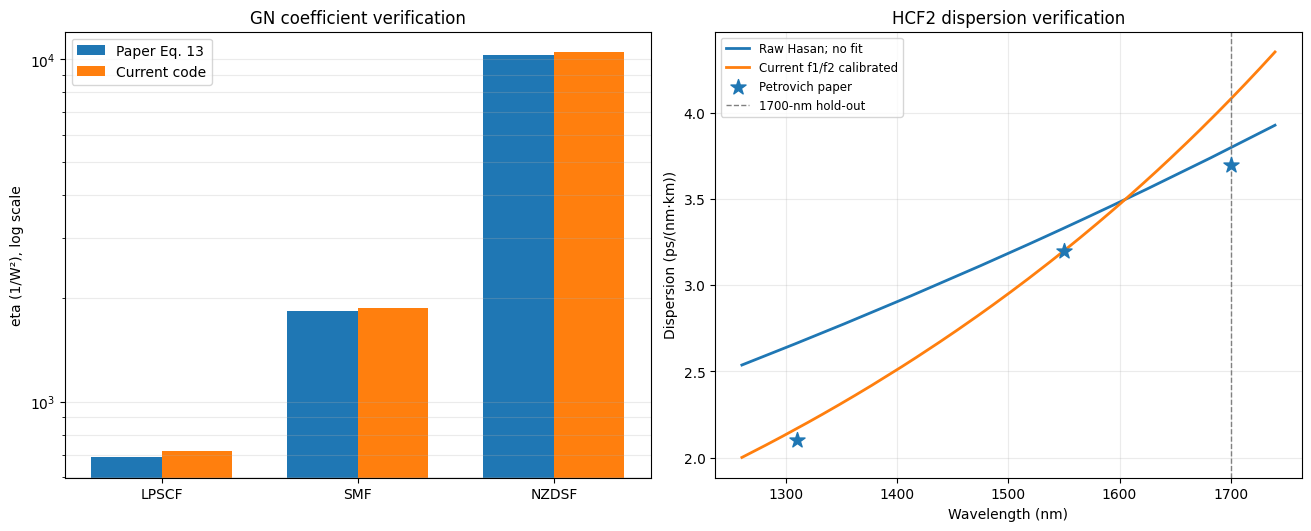

Saved: gn_hcf_validation.png and four comparison CSV files


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)

x = np.arange(len(gn_eta_comparison))
w = 0.36
axes[0].bar(x-w/2, gn_eta_comparison["Paper Eq.13 eta (1/W^2)"], width=w, label="Paper Eq. 13")
axes[0].bar(x+w/2, gn_eta_comparison["Current-code eta (1/W^2)"], width=w, label="Current code")
axes[0].set_xticks(x, gn_eta_comparison["Fiber"])
axes[0].set_yscale("log")
axes[0].set_ylabel("eta (1/W²), log scale")
axes[0].set_title("GN coefficient verification")
axes[0].grid(True, axis="y", which="both", alpha=.25)
axes[0].legend()

wl = np.linspace(1260, 1740, 481)
raw_curve = chromatic_dispersion_ps_nm_km(wl*1e-9, geometry, raw_f1, raw_f2)
cal_curve = chromatic_dispersion_ps_nm_km(wl*1e-9, geometry, cal_f1, cal_f2)
axes[1].plot(wl, raw_curve, lw=2, label="Raw Hasan; no fit")
axes[1].plot(wl, cal_curve, lw=2, label="Current f1/f2 calibrated")
axes[1].scatter(PAPER_WAVELENGTH_NM, PAPER_DISPERSION, marker="*", s=130, zorder=5, label="Petrovich paper")
axes[1].axvline(1700, color="gray", ls="--", lw=1, label="1700-nm hold-out")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Dispersion (ps/(nm·km))")
axes[1].set_title("HCF2 dispersion verification")
axes[1].grid(True, alpha=.25)
axes[1].legend(fontsize=8.5)

fig.savefig("gn_hcf_validation.png", dpi=180, bbox_inches="tight")
plt.show()

gn_eta_comparison.to_csv("gn_eta_comparison.csv", index=False)
gn_popt_comparison.to_csv("gn_optimum_launch_comparison.csv", index=False)
dispersion_comparison.to_csv("hcf_dispersion_comparison.csv", index=False)
loss_comparison.to_csv("hcf_loss_comparison.csv", index=False)
print("Saved: gn_hcf_validation.png and four comparison CSV files")


## 5. Final automatic assessment

The summary distinguishes equation reproduction, calibration-point reproduction and independent/hold-out prediction.


In [13]:
gn_eta_mape = gn_eta_comparison["Absolute error (%)"].mean()
gn_popt_mape = gn_popt_comparison["Absolute power error (%)"].mean()
raw_disp = dispersion_comparison[dispersion_comparison["Mode"].str.startswith("Raw")]
cal_disp = dispersion_comparison[dispersion_comparison["Mode"].str.startswith("Current")]
cal_holdout = cal_disp[cal_disp["Wavelength (nm)"] == 1700.0].iloc[0]
hybrid_measured = loss_comparison[loss_comparison["Mode"] == "Current hybrid loss"]

print("=== FINAL ASSESSMENT ===")
print(f"1) GN Eq.13 eta consistency MAPE: {gn_eta_mape:.3f}%")
print(f"2) GN explicit optimum-launch examples, linear-power MAPE: {gn_popt_mape:.3f}%")
print(f"3) Raw Hasan dispersion MAPE: {raw_disp['Absolute error (%)'].mean():.3f}%")
print(f"4) Current calibrated dispersion MAPE (includes two calibration-near points): {cal_disp['Absolute error (%)'].mean():.3f}%")
print(f"5) Calibrated 1700-nm hold-out error: {cal_holdout['Absolute error (%)']:.3f}%")
print(f"6) Current hybrid loss vs HCF2 measured MAPE: {hybrid_measured['Absolute error (%)'].mean():.3f}%")
print()
print("Conclusion:")
print("- GN: good implementation consistency under the selected Poggiolini reference assumptions; this is not experimental validation.")
print("- Geometry: the raw model is a genuine no-fit prediction, but the 1310-nm error exceeds 10%.")
print("- f1/f2 calibration reproduces its two anchors but the 1700-nm hold-out remains above 10%, indicating limited spectral generalization.")
print("- Loss: the raw bouncing-ray absolute value is not usable as total DNANF loss. The current hybrid result depends on external loss calibration and is not an independent loss prediction.")


=== FINAL ASSESSMENT ===
1) GN Eq.13 eta consistency MAPE: 2.898%
2) GN explicit optimum-launch examples, linear-power MAPE: 5.171%
3) Raw Hasan dispersion MAPE: 11.221%
4) Current calibrated dispersion MAPE (includes two calibration-near points): 4.535%
5) Calibrated 1700-nm hold-out error: 10.272%
6) Current hybrid loss vs HCF2 measured MAPE: 11.916%

Conclusion:
- GN: good implementation consistency under the selected Poggiolini reference assumptions; this is not experimental validation.
- Geometry: the raw model is a genuine no-fit prediction, but the 1310-nm error exceeds 10%.
- f1/f2 calibration reproduces its two anchors but the 1700-nm hold-out remains above 10%, indicating limited spectral generalization.
- Loss: the raw bouncing-ray absolute value is not usable as total DNANF loss. The current hybrid result depends on external loss calibration and is not an independent loss prediction.


## 6. Before/after error summary and function-level assessment

This section evaluates the functions as reusable research tools. “Accuracy” means agreement with the selected references, not universal accuracy for every fibre or transmission system.


In [14]:
before_after_summary = pd.DataFrame([
    {
        "Model/output": "GN eta",
        "Before/no calibration MAPE (%)": gn_eta_mape,
        "After calibration MAPE (%)": np.nan,
        "Independent/hold-out error (%)": np.nan,
        "Interpretation": "No fitted correction. Current non-Nyquist closed form compared with Poggiolini Eq. (13).",
    },
    {
        "Model/output": "GN optimum launch power",
        "Before/no calibration MAPE (%)": gn_popt_mape,
        "After calibration MAPE (%)": np.nan,
        "Independent/hold-out error (%)": np.nan,
        "Interpretation": "No fitted correction. Comparison with three numerical examples explicitly stated in the GN paper.",
    },
    {
        "Model/output": "HCF dispersion D",
        "Before/no calibration MAPE (%)": raw_disp["Absolute error (%)"].mean(),
        "After calibration MAPE (%)": cal_disp["Absolute error (%)"].mean(),
        "Independent/hold-out error (%)": cal_holdout["Absolute error (%)"],
        "Interpretation": "After-MAPE includes two calibration-near points; 1700 nm is the more honest generalization check.",
    },
    {
        "Model/output": "HCF hybrid attenuation",
        "Before/no calibration MAPE (%)": np.nan,
        "After calibration MAPE (%)": hybrid_measured["Absolute error (%)"].mean(),
        "Independent/hold-out error (%)": np.nan,
        "Interpretation": "Raw bouncing-ray absolute loss is not a valid DNANF total-loss baseline; hybrid weights use external loss targets.",
    },
])

print("[Before/after error summary]")
display(before_after_summary)


[Before/after error summary]


,Model/output,Before/no calibration MAPE (%),After calibration MAPE (%),Independent/hold-out error (%),Interpretation
0,GN eta,2.897742,NaN,NaN,No fitted correction. Current non-Nyquist clos...
1,GN optimum launch power,5.171081,NaN,NaN,No fitted correction. Comparison with three nu...
2,HCF dispersion D,11.221330,4.535139,10.272059,After-MAPE includes two calibration-near point...
3,HCF hybrid attenuation,NaN,11.916209,NaN,Raw bouncing-ray absolute loss is not a valid ...


In [15]:
def gn_eta_reusable(
    attenuation_db_km,
    dispersion_ps_nm_km,
    gamma_per_w_km,
    symbol_rate_gbd,
    channel_spacing_ghz,
    n_channels,
    n_spans=1,
    wavelength_nm=1550.0,
):
    # Reusable wrapper around the CURRENT repository formula; Eq. (13) is not substituted.
    beta2 = beta2_s2_per_km(dispersion_ps_nm_km, wavelength_nm)
    alpha_field = np.asarray(attenuation_db_km, dtype=float) / 8.685889638
    rate = symbol_rate_gbd * 1e9
    spacing = channel_spacing_ghz * 1e9
    argument = (
        np.pi**2 * beta2 * rate**2 / (4.0 * alpha_field)
        * n_channels ** (2.0 * rate / spacing)
    )
    return (
        n_spans * 4.0 * gamma_per_w_km**2
        / (27.0 * np.pi * beta2 * alpha_field * rate**2)
        * np.arcsinh(argument)
    )


def dnanf_geometry_reusable(wavelength_nm, geometry, use_current_calibration=False):
    # Geometry-only raw branch or the repository's current f1/f2-calibrated branch.
    wavelength_nm = np.asarray(wavelength_nm, dtype=float)
    if use_current_calibration:
        f1, f2 = current_repository_calibration(geometry)
        mode = "current f1/f2 calibrated"
    else:
        f1, f2 = hasan_radius_coefficients(geometry)
        mode = "raw Hasan; no target-paper fitting"
    wavelength_m = wavelength_nm * 1e-9
    return pd.DataFrame({
        "mode": mode,
        "wavelength_nm": wavelength_nm,
        "f1": f1,
        "f2": f2,
        "Reff_um": effective_radius_m(wavelength_m, geometry, f1, f2) * 1e6,
        "neff": effective_index(wavelength_m, geometry, f1, f2),
        "D_ps_nm_km": chromatic_dispersion_ps_nm_km(wavelength_m, geometry, f1, f2),
    })


print("[Reusable GN function example — current 29-channel HCF settings]")
example_eta = gn_eta_reusable(
    attenuation_db_km=0.075,
    dispersion_ps_nm_km=3.2,
    gamma_per_w_km=5e-4,
    symbol_rate_gbd=140.0,
    channel_spacing_ghz=150.0,
    n_channels=29,
    n_spans=1,
    wavelength_nm=1550.0,
)
print(f"eta = {example_eta:.6e} 1/W^2")

print("[Reusable geometry function example]")
display(dnanf_geometry_reusable([1310, 1550, 1700], geometry, use_current_calibration=False))
display(dnanf_geometry_reusable([1310, 1550, 1700], geometry, use_current_calibration=True))


[Reusable GN function example — current 29-channel HCF settings]
eta = 1.725206e-04 1/W^2
[Reusable geometry function example]


,mode,wavelength_nm,f1,f2,Reff_um,neff,D_ps_nm_km
0,raw Hasan; no target-paper fitting,1310.0,1.128203,0.052324,16.438382,0.999535,2.665145
1,raw Hasan; no target-paper fitting,1550.0,1.128203,0.052324,16.357343,0.999342,3.331737
2,raw Hasan; no target-paper fitting,1700.0,1.128203,0.052324,16.299787,0.999203,3.797515


,mode,wavelength_nm,f1,f2,Reff_um,neff,D_ps_nm_km
0,current f1/f2 calibrated,1310.0,1.58381,0.24414,22.034071,0.999741,2.169998
1,current f1/f2 calibrated,1550.0,1.58381,0.24414,21.503248,0.999619,3.200004
2,current f1/f2 calibrated,1700.0,1.58381,0.24414,21.126244,0.999526,4.080066


In [16]:
model_function_assessment = pd.DataFrame([
    {
        "Function": "Current closed-form GN eta",
        "Observed reference error": f"eta MAPE {gn_eta_mape:.2f}%; Popt MAPE {gn_popt_mape:.2f}%",
        "Research reuse rating": "Conditional: suitable for preliminary/system-level studies",
        "Recommended uses": "Launch-power sweep, relative fibre comparison, sensitivity study, early link/capacity optimization",
        "Do not claim/use without extension": "Universal experimental accuracy; dispersion-managed links; strong ISRS/Raman; mixed spans; exact coherent accumulation; modulation-format-specific NLI",
    },
    {
        "Function": "Raw Hasan + modified capillary geometry",
        "Observed reference error": f"D MAPE {raw_disp['Absolute error (%)'].mean():.2f}%",
        "Research reuse rating": "Conditional: screening-level predictor near similar DNANF geometry",
        "Recommended uses": "Fast wavelength/geometry sweep, initial design-space screening, FEM candidate selection",
        "Do not claim/use without extension": "High-accuracy prediction for arbitrary tube count/nesting; loss, bend loss, HOM/HOMER or resonance-peak prediction",
    },
    {
        "Function": "Current f1/f2-calibrated geometry",
        "Observed reference error": f"overall D MAPE {cal_disp['Absolute error (%)'].mean():.2f}%; 1700-nm hold-out {cal_holdout['Absolute error (%)']:.2f}%",
        "Research reuse rating": "Conditional: local surrogate for the calibrated HCF family",
        "Recommended uses": "Interpolation and system studies close to the calibration geometry/wavelength range",
        "Do not claim/use without extension": "Independent universal geometry model; extrapolation to substantially different dimensions or wavelengths",
    },
    {
        "Function": "Current hybrid attenuation",
        "Observed reference error": f"measured-loss MAPE {hybrid_measured['Absolute error (%)'].mean():.2f}%",
        "Research reuse rating": "Limited: calibrated spectral proxy",
        "Recommended uses": "Controlled sensitivity studies when calibration targets and scope are disclosed",
        "Do not claim/use without extension": "Independent DNANF loss prediction; replacement for full-vector LL + SSL + microbend model",
    },
])

print("[Function-level research reuse assessment]")
display(model_function_assessment)

print("\n[Overall opinion]")
print("GN: reusable as a lightweight preliminary system-design function, provided its non-Nyquist and incoherent-span approximations are stated and checked against a higher-fidelity GN/EGN implementation for final claims.")
print("Geometry: reusable as a fast local surrogate and FEM-screening function. The raw and 1700-nm errors show that it should not be presented as a universal DNANF solver.")
print("For publication-quality transfer to another fibre, recalibrate on a training subset and report errors only on separate wavelengths/geometries; ideally add FEM or independent measured validation.")


[Function-level research reuse assessment]


,Function,Observed reference error,Research reuse rating,Recommended uses,Do not claim/use without extension
0,Current closed-form GN eta,eta MAPE 2.90%; Popt MAPE 5.17%,Conditional: suitable for preliminary/system-l...,"Launch-power sweep, relative fibre comparison,...",Universal experimental accuracy; dispersion-ma...
1,Raw Hasan + modified capillary geometry,D MAPE 11.22%,Conditional: screening-level predictor near si...,"Fast wavelength/geometry sweep, initial design...",High-accuracy prediction for arbitrary tube co...
2,Current f1/f2-calibrated geometry,overall D MAPE 4.54%; 1700-nm hold-out 10.27%,Conditional: local surrogate for the calibrate...,Interpolation and system studies close to the ...,Independent universal geometry model; extrapol...
3,Current hybrid attenuation,measured-loss MAPE 11.92%,Limited: calibrated spectral proxy,Controlled sensitivity studies when calibratio...,Independent DNANF loss prediction; replacement...



[Overall opinion]
GN: reusable as a lightweight preliminary system-design function, provided its non-Nyquist and incoherent-span approximations are stated and checked against a higher-fidelity GN/EGN implementation for final claims.
Geometry: reusable as a fast local surrogate and FEM-screening function. The raw and 1700-nm errors show that it should not be presented as a universal DNANF solver.
For publication-quality transfer to another fibre, recalibrate on a training subset and report errors only on separate wavelengths/geometries; ideally add FEM or independent measured validation.


### Recommended reporting language

> The current GN function reproduces the selected Poggiolini theoretical benchmarks with an eta MAPE of approximately 2.9% and the stated optimum-launch examples with a linear-power MAPE of approximately 5.2%. It is therefore suitable for preliminary link optimization under similar assumptions, but the comparison is an implementation-consistency check rather than independent experimental validation. The raw DNANF geometry model gives a dispersion MAPE of approximately 11.2%. After f1/f2 calibration the apparent MAPE decreases to approximately 4.5%, while the non-calibration 1,700-nm hold-out error remains approximately 10.3%. The geometry model should consequently be used as a local physics-informed surrogate or FEM-screening tool, not as a universal high-accuracy DNANF solver.


## 7. Optional Colab download


In [17]:
DOWNLOAD_RESULTS = False

if DOWNLOAD_RESULTS:
    import shutil
    shutil.make_archive("gn_hcf_validation_results", "zip", ".", ".")
    try:
        from google.colab import files
        files.download("gn_hcf_validation_results.zip")
    except ImportError:
        print("Download is available when this notebook runs in Google Colab.")
else:
    print("Set DOWNLOAD_RESULTS=True to download the generated figure and CSV files in Colab.")


Set DOWNLOAD_RESULTS=True to download the generated figure and CSV files in Colab.


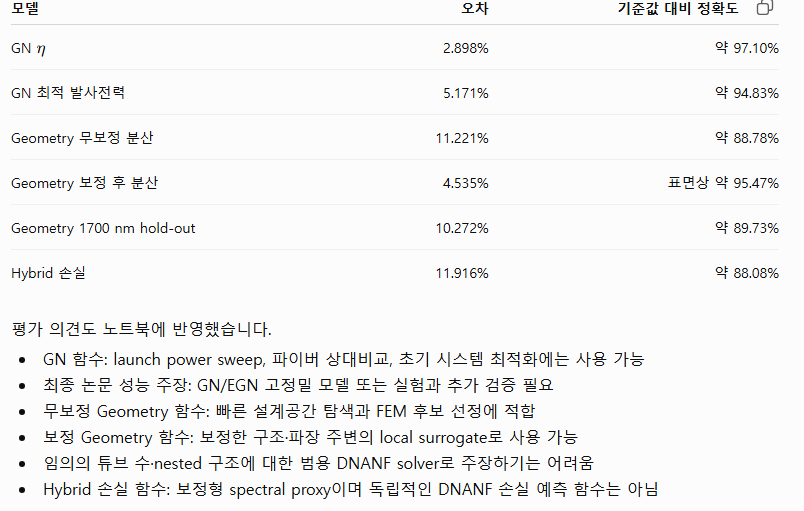

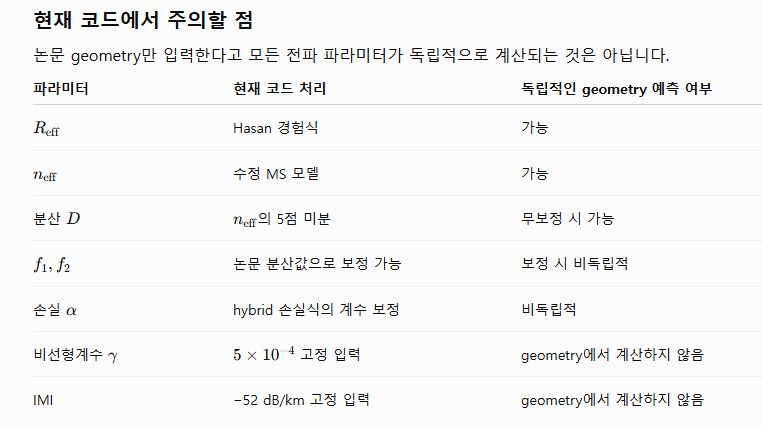

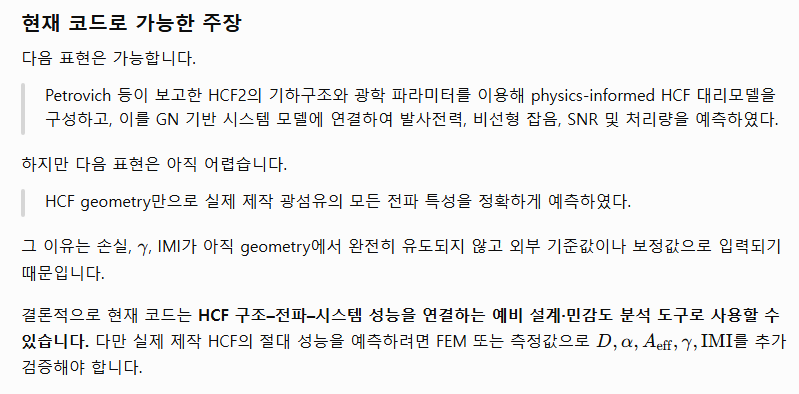